In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
# import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import minimize
import importlib
import fit_thermal_rc_model
import sys
import datetime

sys.path.append(r"D:\Jupyter\CrystaLiZe\CrystaLiZe-SlowControlsData-main")
from crystalize_slowcontrolsdata.boxDownload import readBoxCSV

import matplotlib.pyplot as plt
import matplotlib as mpl
plt.style.use("default")
mpl.rcdefaults()

importlib.reload(fit_thermal_rc_model)
from fit_thermal_rc_model import (
    plot_fit,
    plot_validation,
    save_results,
    save_validation_results,
    validate_experiment_arrays,
    print_validation_summary, 
)

In [2]:
def coldhead_power_with_efficiency(CH_temp, eff):
    # corrected coldhead power in cases where coldhead is < 100% efficient
    # ideally, 0 < eff <= 1
    a = 8.17430058
    b = 22.45378994
    power = a * np.sqrt(CH_temp - b)
    power = eff * power
    return power

In [3]:
path = r"D:\CrystaLiZe\2026-02-23 20_55_53.csv"
df = pd.read_csv(path)
start_time = '2026-02-24 13:40:00'
end_time = '2026-03-2 15:00:00'
df = df[df['Time'].between(start_time, end_time)]

time = pd.to_datetime(df['Time'], format='%Y-%m-%d %H_%M_%S')
time_relative = df['Elapsed Time(s)'].to_numpy()
bot_flange = df['RTDD3 Temperature(K)'].to_numpy()
top_flange = df['RTDD4 Temperature(K)'].to_numpy()
Heater1 = df['Heater1 Output(W)'].to_numpy()
Heater2 = df['Heater2 Output(W)'].to_numpy()
CH_temp = df['RTDD5 Temperature(K)'].to_numpy()
CH_power = coldhead_power_with_efficiency(CH_temp, eff=1)
CH_power = np.asarray(CH_power, dtype=float)


In [3]:
# # 7c
# start_time = datetime.datetime(2026, 2, 28, 20, 30, 0)
# end_time = datetime.datetime(2026, 3, 2, 12, 0, 0)
# 7d
start_time = datetime.datetime(2026, 3, 7, 21, 30, 0)
end_time = datetime.datetime(2026, 3, 9, 6, 0, 0)
# 7f
# start_time = datetime.datetime(2026, 3, 13, 8, 0, 0)
# end_time = datetime.datetime(2026, 3, 14, 11, 0, 0)
# 7g
# start_time = datetime.datetime(2026, 3, 17, 17, 17, 0)
# end_time = datetime.datetime(2026, 3, 18, 12, 20, 0)
# 7h
# start_time = datetime.datetime(2026, 3, 19, 10, 52, 0)
# end_time = datetime.datetime(2026, 3, 22, 1, 40, 0)
# 7i
# start_time = datetime.datetime(2026, 3, 29, 5, 24, 0)
# end_time = datetime.datetime(2026, 3, 30, 8, 0, 0)
# # 7j
# start_time = datetime.datetime(2026, 3, 31, 15, 40, 0)
# end_time = datetime.datetime(2026, 4, 2, 3, 0, 0)
# # 7k
# start_time = datetime.datetime(2026, 4, 10, 4, 40, 0)
# end_time = datetime.datetime(2026, 4, 11, 19, 0, 0)


In [4]:
df = readBoxCSV(
    key="Lakeshore",
    timeCol="Time",
    start_time=start_time,
    end_time=end_time,
    download=True,
    return_df=True
)
# df["Time"] = pd.to_datetime(df["Time"], format="%Y-%m-%d %H_%M_%S", errors="coerce")
print(df.shape)


2026-03-07 13_19_57.csv: 47.0MB [00:00, 101MB/s] 


(91475, 26)


In [9]:
start_time = '2026-03-08 2:40:00'
end_time = '2026-03-09 06:00:00'
df_selected = df[df['Time'].between(start_time, end_time)]
time = df_selected['Time']
time_relative = df_selected['Elapsed Time(s)'].to_numpy()
bot_flange = df_selected['RTDD3 Temperature(K)'].to_numpy()
top_flange = df_selected['RTDD4 Temperature(K)'].to_numpy()
Heater1 = df_selected['Heater1 Output(W)'].to_numpy()
Heater2 = df_selected['Heater2 Output(W)'].to_numpy()
CH_temp = df_selected['RTDD5 Temperature(K)'].to_numpy()
CH_power = coldhead_power_with_efficiency(CH_temp, eff=1)
CH_power = np.asarray(CH_power, dtype=float)

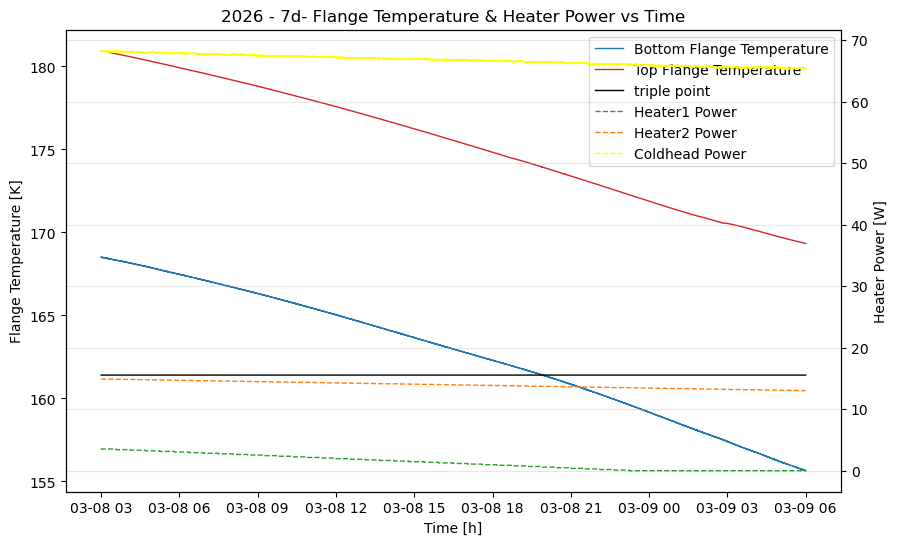

In [11]:
HeaterCH = coldhead_power_with_efficiency(CH_temp, 1)
Heateri0 = HeaterCH-Heater1-Heater2
triple = [161.406] * len(time)

fig, ax1 = plt.subplots(figsize=(10, 6))

line11 = ax1.plot(time, bot_flange, color='tab:blue', linewidth=1, label='Bottom Flange Temperature')
line12 = ax1.plot(time, top_flange, color='tab:red', linewidth=1, label='Top Flange Temperature')
# line13 = ax1.plot(time, CH_temp, color='purple', linewidth=0.5, label='coldhead Temperature')
# line13 = ax1.plot(time, top_flange-bot_flange, color='purple', linewidth=0.5, label='Temperature difference')
line14 = ax1.plot(time, triple, color='black', linewidth=1, label='triple point')

ax1.set_xlabel('Time [h]')
ax1.set_ylabel('Flange Temperature [K]')
# ax1.tick_params(axis='y', labelcolor='tab:blue')  
ax2 = ax1.twinx()

line21 = ax2.plot(time, Heater1, color='tab:green', linestyle='--', linewidth=1, label='Heater1 Power')
line22 = ax2.plot(time, Heater2, color='tab:orange', linestyle='--', linewidth=1, label='Heater2 Power')
line23 = ax2.plot(time, HeaterCH, color='yellow', linestyle='--', linewidth=1, label='Coldhead Power')
# line24 = ax2.plot(time, Heateri0, color='black', linestyle='--', linewidth=0.5, label='i0 Power')

ax2.set_ylabel('Heater Power [W]')
# ax2.tick_params(axis='y', labelcolor='tab:red')

lines = line11 + line12 + line14 + line21 + line22 + line23 # + line24
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

title_string = "2026 - 7d- Flange Temperature & Heater Power vs Time"
plt.title(title_string)

plt.grid(True, alpha=0.3)
# plt.tight_layout()
plt.show()

In [16]:
print(top_flange-bot_flange)
print(np.min(top_flange-bot_flange))
print(np.max(top_flange-bot_flange))
print(np.mean(top_flange-bot_flange))

[12.484 12.483 12.485 ... 13.691 13.687 13.688]
12.427999999999997
13.691000000000003
12.642459713139525


In [12]:
# path = f"D:\\CrystaLiZe\\2026-03-07 13_19_57.csv"
# df = pd.read_csv(path)
# time = pd.to_datetime(df['Time'], format='%Y-%m-%d %H_%M_%S')
start_time = '2026-03-8 3:00:00'
end_time = '2026-03-8 20:00:00'

df_selected = df[
    df['Time'].between(start_time, end_time)]

time = df_selected['Time']
time_relative = df_selected['Elapsed Time(s)'].to_numpy()
bot_flange = df_selected['RTDD3 Temperature(K)'].to_numpy()
top_flange = df_selected['RTDD4 Temperature(K)'].to_numpy()
Heater1 = df_selected['Heater1 Output(W)'].to_numpy()
Heater2 = df_selected['Heater2 Output(W)'].to_numpy()
CH_temp = df_selected['RTDD5 Temperature(K)'].to_numpy()
CH_power = coldhead_power_with_efficiency(CH_temp, eff=1)
CH_power = np.asarray(CH_power, dtype=float)

print(f"Selected rows: {len(df_selected)}")
print(df_selected["Time"].min())
print(df_selected["Time"].max())

Selected rows: 49232
2026-03-08 03:00:01
2026-03-08 20:00:00


In [13]:
def find_time_gaps(frame, threshold_s=60):
    times = (
        frame["Time"]
        .dropna()
        .drop_duplicates()
        .sort_values()
        .reset_index(drop=True)
    )

    gaps = pd.DataFrame({
        "gap_start": times.shift(1),
        "gap_end": times,
        "gap_seconds": times.diff().dt.total_seconds(),
    })

    return gaps.loc[
        gaps["gap_seconds"] > threshold_s
    ].reset_index(drop=True)

gaps = find_time_gaps(df_selected)

print(gaps.to_string(index=False))

Empty DataFrame
Columns: [gap_start, gap_end, gap_seconds]
Index: []


In [ ]:
from fit_thermal_rc_model import (
    ThermalParameters,
    fit_experiment_arrays,
    print_fit_summary,
    plot_fit,
    save_results,
)

initial_guess = ThermalParameters(
    R_tb=1/2.06,       # K/W
    R_tc=1/0.32768, # K/W
    R_bc=1/0.75838, # K/W
    C_t=5.0e2,      # J/K
    C_b=5.0e2,      # J/K
    C_CH=0,     # J/K
    # i0=50,
)

result, actual_dt = fit_experiment_arrays(
    time_relative=time,
    bot_flange=bot_flange,
    top_flange=top_flange,
    CH_temp=CH_temp,
    CH_power=CH_power,
    Heater1=Heater1,
    Heater2=Heater2,

    fit_dt_s=5.0,
    max_gap_s=60.0,
    initial=initial_guess,

    temperature_sigma_k=(0.02, 0.02, 0.5),

    max_nfev=300,
)

print(f"Actual fitting time step: {actual_dt:.3f} s")
print_fit_summary(result)

`ftol` termination condition is satisfied.
Function evaluations 24, initial cost 1.4752e+07, final cost 1.9321e+05, first-order optimality 6.38e+01.
Actual fitting time step: 5.000 s
Fitted parameters
  R_tb  = 0.26157328 +/- 0.0676 K/W
  R_tc  = 3.0517578 K/W (fixed)
  R_bc  = 1.3186002 K/W (fixed)
  C_t   = 100000 +/- 1.14e+05 J/K
  C_b   = 63810.985 +/- 1.12e+05 J/K
  C_CH  = 0 J/K (fixed)
  i0(T_top) = -0.3348 * T_top + 110.7 W (T_top in K)
Fit targets         = T_t, T_b; measured T_CH is the boundary input
success             = True
reduced chi-square  = 100.68
optimizer message   = `ftol` termination condition is satisfied.


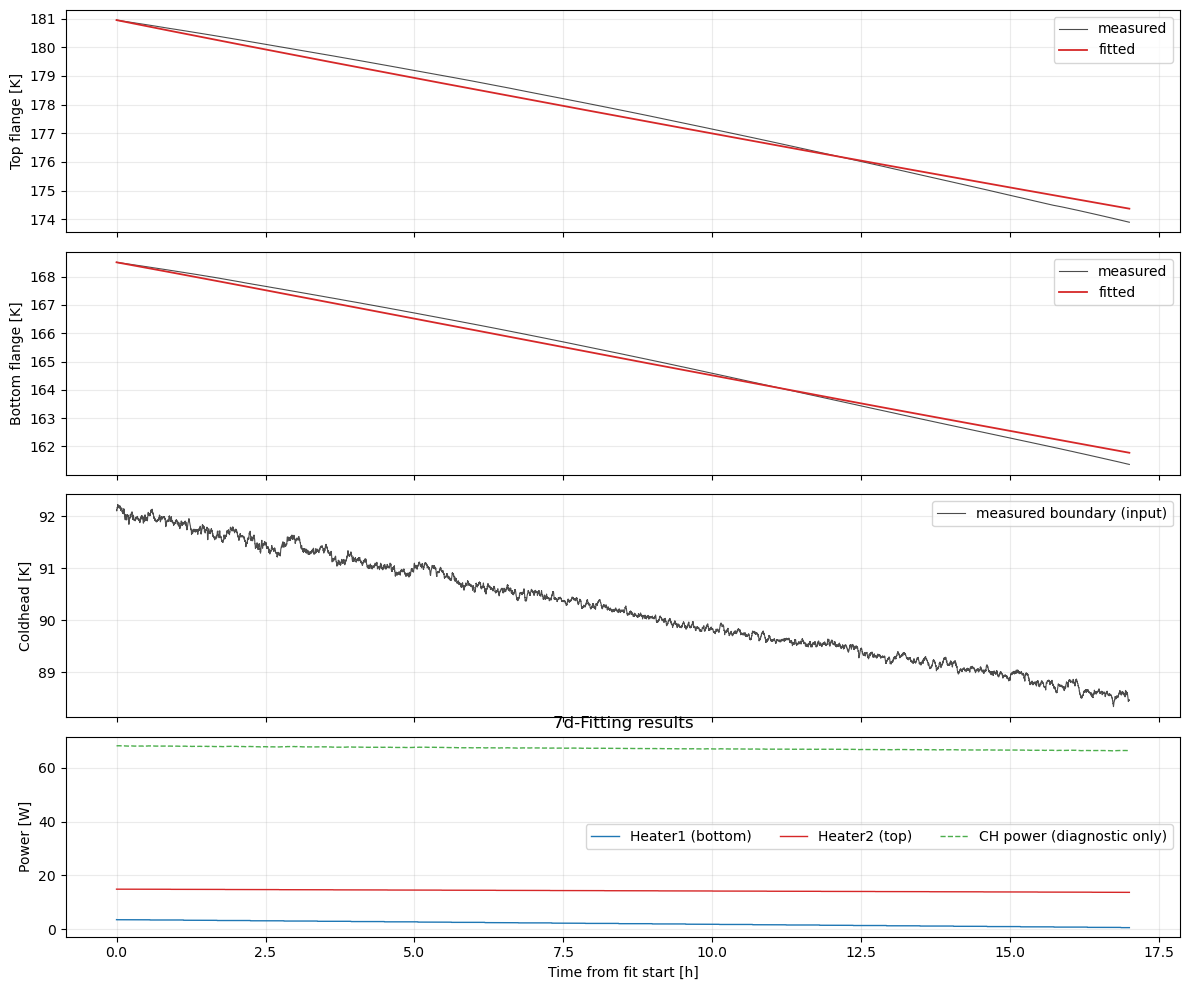

In [15]:
fig, axes = plot_fit(result)
plt.title('7d-Fitting results')
plt.show()

In [16]:
fitted_parameters = result.parameters

In [22]:
path_new = r"D:\CrystaLiZe\2026-03-17 22_37_44.csv"
df_new = pd.read_csv(path_new)

df_new["Time"] = pd.to_datetime(
    df_new["Time"],
    format="%Y-%m-%d %H_%M_%S",
    errors="coerce",
)

validation_start = pd.Timestamp("2026-03-17 23:00:00")
validation_end = pd.Timestamp("2026-03-18 14:00:00")

df_validation = df_new.loc[
    df_new["Time"].between(validation_start, validation_end)
].copy()

print(f"Selected rows: {len(df_validation)}")
print(df_validation["Time"].min())
print(df_validation["Time"].max())

time_validation = df_validation["Elapsed Time(s)"].to_numpy(dtype=float)
bot_validation = df_validation["RTDD3 Temperature(K)"].to_numpy(dtype=float)
top_validation = df_validation["RTDD4 Temperature(K)"].to_numpy(dtype=float)
CH_temp_validation = df_validation["RTDD5 Temperature(K)"].to_numpy(dtype=float)
Heater1_validation = df_validation["Heater1 Output(W)"].to_numpy(dtype=float)
Heater2_validation = df_validation["Heater2 Output(W)"].to_numpy(dtype=float)
CH_power_validation = coldhead_power_with_efficiency(CH_temp_validation, eff=1)
CH_power_validation = np.asarray(CH_power_validation, dtype=float)

Selected rows: 42404
2026-03-17 23:00:00
2026-03-18 14:00:00


In [ ]:
validation_result, validation_dt = validate_experiment_arrays(
    parameters=fitted_parameters,

    time_relative=time_validation,
    bot_flange=bot_validation,
    top_flange=top_validation,
    CH_temp=CH_temp_validation,
    CH_power=CH_power_validation,
    Heater1=Heater1_validation,
    Heater2=Heater2_validation,

    # 最好与拟合阶段采用相同时间步长
    fit_dt_s=5.0,
    # 0 表示整个验证时段都参与误差统计
    metric_start_s=0.0,
)

print(f"Validation time step: {validation_dt:.3f} s")
print_validation_summary(validation_result)

Validation time step: 5.000 s
Validation metrics (measured - predicted)
T_CH is a measured boundary input; it has no prediction-error metric.
Metrics start at t = 0.000 s

T_t
  RMSE          = 2.57361 K
  MAE           = 2.3867 K
  bias          = -2.3867 K
  max abs error = 3.5164 K
  R^2           = -0.120029

T_b
  RMSE          = 0.822829 K
  MAE           = 0.774361 K
  bias          = 0.774361 K
  max abs error = 1.07682 K
  R^2           = 0.865559


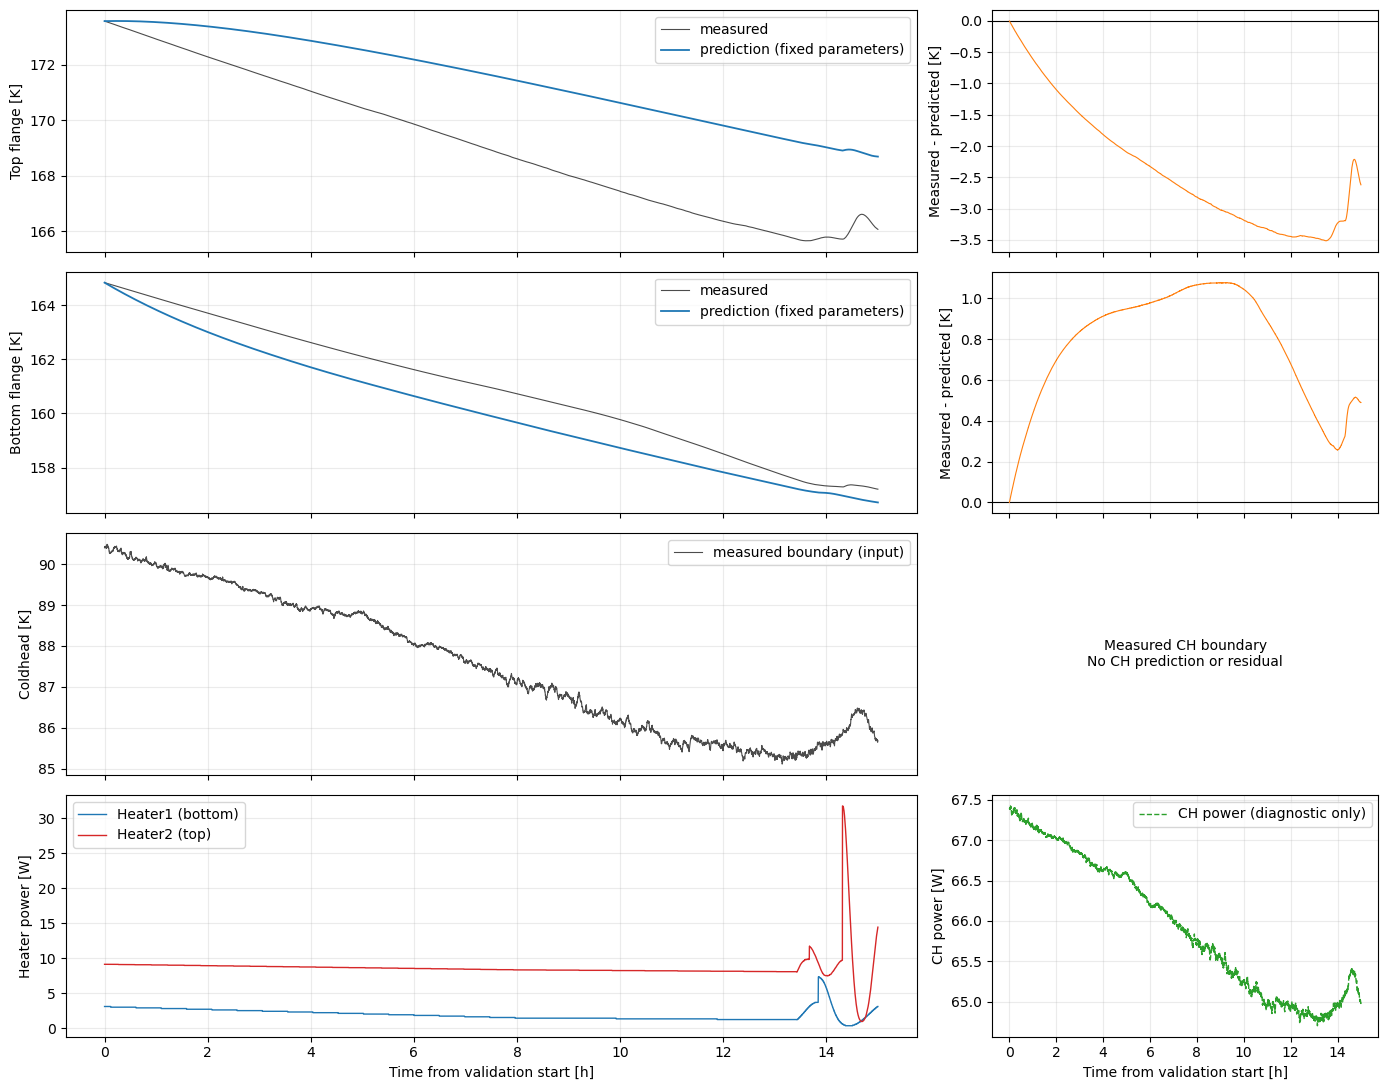

In [24]:
fig, axes = plot_validation(validation_result)
plt.show()

In [37]:
path_new = r"D:\CrystaLiZe\2026-02-23 20_55_53.csv"
df_new = pd.read_csv(path_new)

df_new["Time"] = pd.to_datetime(
    df_new["Time"],
    format="%Y-%m-%d %H_%M_%S",
    errors="coerce",
)

validation_start = pd.Timestamp("2026-02-28 4:00:00")
validation_end = pd.Timestamp("2026-02-28 20:00:00")

df_validation = df_new.loc[
    df_new["Time"].between(validation_start, validation_end)
].copy()

print(f"Selected rows: {len(df_validation)}")
print(df_validation["Time"].min())
print(df_validation["Time"].max())

time_validation = df_validation["Elapsed Time(s)"].to_numpy(dtype=float)
bot_validation = df_validation["RTDD3 Temperature(K)"].to_numpy(dtype=float)
top_validation = df_validation["RTDD4 Temperature(K)"].to_numpy(dtype=float)
CH_temp_validation = df_validation["RTDD5 Temperature(K)"].to_numpy(dtype=float)
Heater1_validation = df_validation["Heater1 Output(W)"].to_numpy(dtype=float)
Heater2_validation = df_validation["Heater2 Output(W)"].to_numpy(dtype=float)
CH_power_validation = coldhead_power_with_efficiency(CH_temp_validation, eff=1)
CH_power_validation = np.asarray(CH_power_validation, dtype=float)

Selected rows: 45337
2026-02-28 04:00:00
2026-02-28 20:00:00


In [38]:
validation_result, validation_dt = validate_experiment_arrays(
    parameters=fitted_parameters,

    time_relative=time_validation,
    bot_flange=bot_validation,
    top_flange=top_validation,
    CH_temp=CH_temp_validation,
    CH_power=CH_power_validation,
    Heater1=Heater1_validation,
    Heater2=Heater2_validation,

    fit_dt_s=5.0,
    metric_start_s=0.0,
)

print(f"Validation time step: {validation_dt:.3f} s")
print_validation_summary(validation_result)

Validation time step: 5.000 s
Validation metrics (measured - predicted)
T_CH is a measured boundary input; it has no prediction-error metric.
Metrics start at t = 0.000 s

T_t
  RMSE          = 2.26791 K
  MAE           = 2.00041 K
  bias          = 2.00041 K
  max abs error = 3.2839 K
  R^2           = -146.294

T_b
  RMSE          = 2.6373 K
  MAE           = 2.37614 K
  bias          = 2.37614 K
  max abs error = 3.73427 K
  R^2           = -217.126


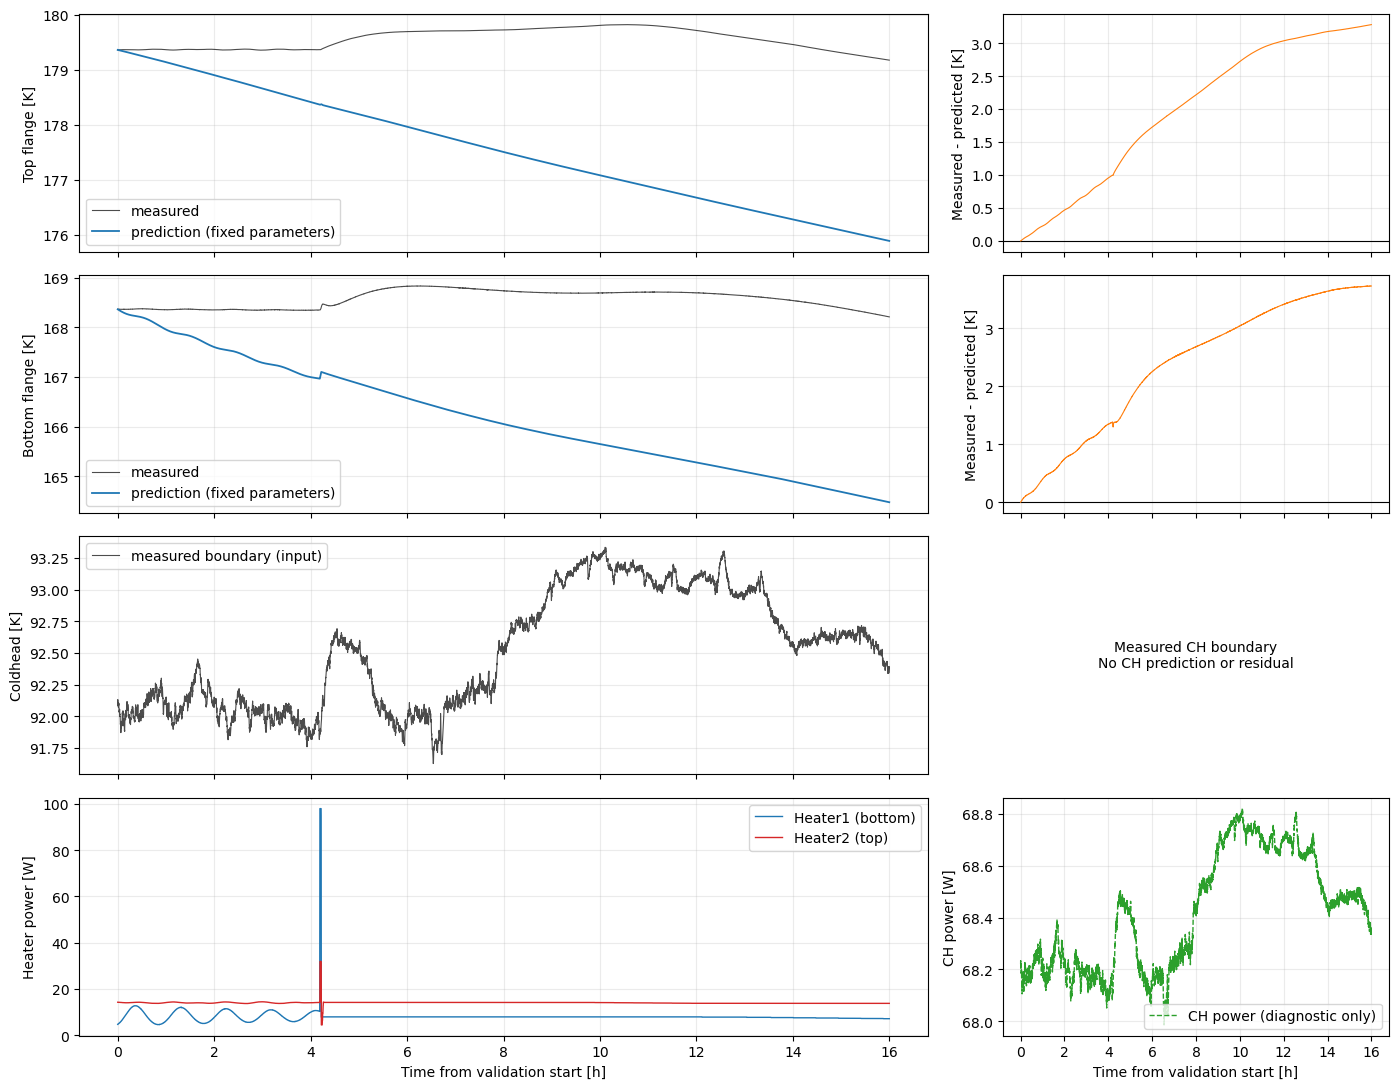

In [39]:
fig, axes = plot_validation(validation_result)
plt.show()

In [26]:
# 7c
# start_time = datetime.datetime(2026, 2, 28, 20, 30, 0)
# end_time = datetime.datetime(2026, 3, 2, 12, 0, 0)
# 7d
# start_time = datetime.datetime(2026, 3, 7, 21, 30, 0)
# end_time = datetime.datetime(2026, 3, 9, 6, 0, 0)
# 7f
# start_time = datetime.datetime(2026, 3, 13, 8, 0, 0)
# end_time = datetime.datetime(2026, 3, 14, 11, 0, 0)
# 7g
# start_time = datetime.datetime(2026, 3, 17, 17, 17, 0)
# end_time = datetime.datetime(2026, 3, 18, 12, 20, 0)
# 7h
# start_time = datetime.datetime(2026, 3, 19, 10, 52, 0)
# end_time = datetime.datetime(2026, 3, 22, 1, 40, 0)
# 7i
# start_time = datetime.datetime(2026, 3, 29, 5, 24, 0)
# end_time = datetime.datetime(2026, 3, 30, 8, 0, 0)
# # 7j
start_time = datetime.datetime(2026, 3, 31, 15, 40, 0)
end_time = datetime.datetime(2026, 4, 2, 3, 0, 0)
# # 7k
# start_time = datetime.datetime(2026, 4, 10, 4, 40, 0)
# end_time = datetime.datetime(2026, 4, 11, 19, 0, 0)
df_new = readBoxCSV(
    key="Lakeshore",
    timeCol="Time",
    start_time=start_time,
    end_time=end_time,
    download=True,
    return_df=True
)
# df["Time"] = pd.to_datetime(
#     df["Time"],
#     format="%Y-%m-%d %H_%M_%S",
#     errors="coerce"
# )
print(df_new.shape)

2026-03-30 18_16_44.csv: 24.0MB [00:00, 123MB/s]
2026-04-01 07_59_51.csv: 51.5MB [00:00, 77.1MB/s]


(97628, 26)


In [27]:
def find_time_gaps(frame, threshold_s=60):
    times = (
        frame["Time"]
        .dropna()
        .drop_duplicates()
        .sort_values()
        .reset_index(drop=True)
    )

    gaps = pd.DataFrame({
        "gap_start": times.shift(1),
        "gap_end": times,
        "gap_seconds": times.diff().dt.total_seconds(),
    })

    return gaps.loc[
        gaps["gap_seconds"] > threshold_s
    ].reset_index(drop=True)

gaps = find_time_gaps(df_new)

print(gaps.to_string(index=False))

Empty DataFrame
Columns: [gap_start, gap_end, gap_seconds]
Index: []


In [30]:
validation_start = pd.Timestamp("2026-03-31 15:40:00")
validation_end = pd.Timestamp("2026-04-02 03:00:00")

df_validation = df_new.loc[
    df_new["Time"].between(validation_start, validation_end)
].copy()

print(f"Selected rows: {len(df_validation)}")
print(df_validation["Time"].min())
print(df_validation["Time"].max())

time_validation = df_validation["Time"]
bot_validation = df_validation["RTDD3 Temperature(K)"].to_numpy(dtype=float)
top_validation = df_validation["RTDD4 Temperature(K)"].to_numpy(dtype=float)
CH_temp_validation = df_validation["RTDD5 Temperature(K)"].to_numpy(dtype=float)
Heater1_validation = df_validation["Heater1 Output(W)"].to_numpy(dtype=float)
Heater2_validation = df_validation["Heater2 Output(W)"].to_numpy(dtype=float)
CH_power_validation = coldhead_power_with_efficiency(CH_temp_validation, eff=1)
CH_power_validation = np.asarray(CH_power_validation, dtype=float)

Selected rows: 97628
2026-03-31 15:40:00
2026-04-02 03:00:00


In [31]:
validation_result, validation_dt = validate_experiment_arrays(
    parameters=fitted_parameters,

    time_relative=time_validation,
    bot_flange=bot_validation,
    top_flange=top_validation,
    CH_temp=CH_temp_validation,
    CH_power=CH_power_validation,
    Heater1=Heater1_validation,
    Heater2=Heater2_validation,

    fit_dt_s=5.0,
    metric_start_s=0.0, 
    max_gap_s = 60,
)

print(f"Validation time step: {validation_dt:.3f} s")
print_validation_summary(validation_result)

Validation time step: 5.000 s
Validation metrics (measured - predicted)
T_CH is a measured boundary input; it has no prediction-error metric.
Metrics start at t = 0.000 s

T_t
  RMSE          = 1.87242 K
  MAE           = 1.68529 K
  bias          = -1.68529 K
  max abs error = 2.66995 K
  R^2           = 0.675817

T_b
  RMSE          = 1.20074 K
  MAE           = 1.00631 K
  bias          = -0.971986 K
  max abs error = 1.91586 K
  R^2           = 0.878926


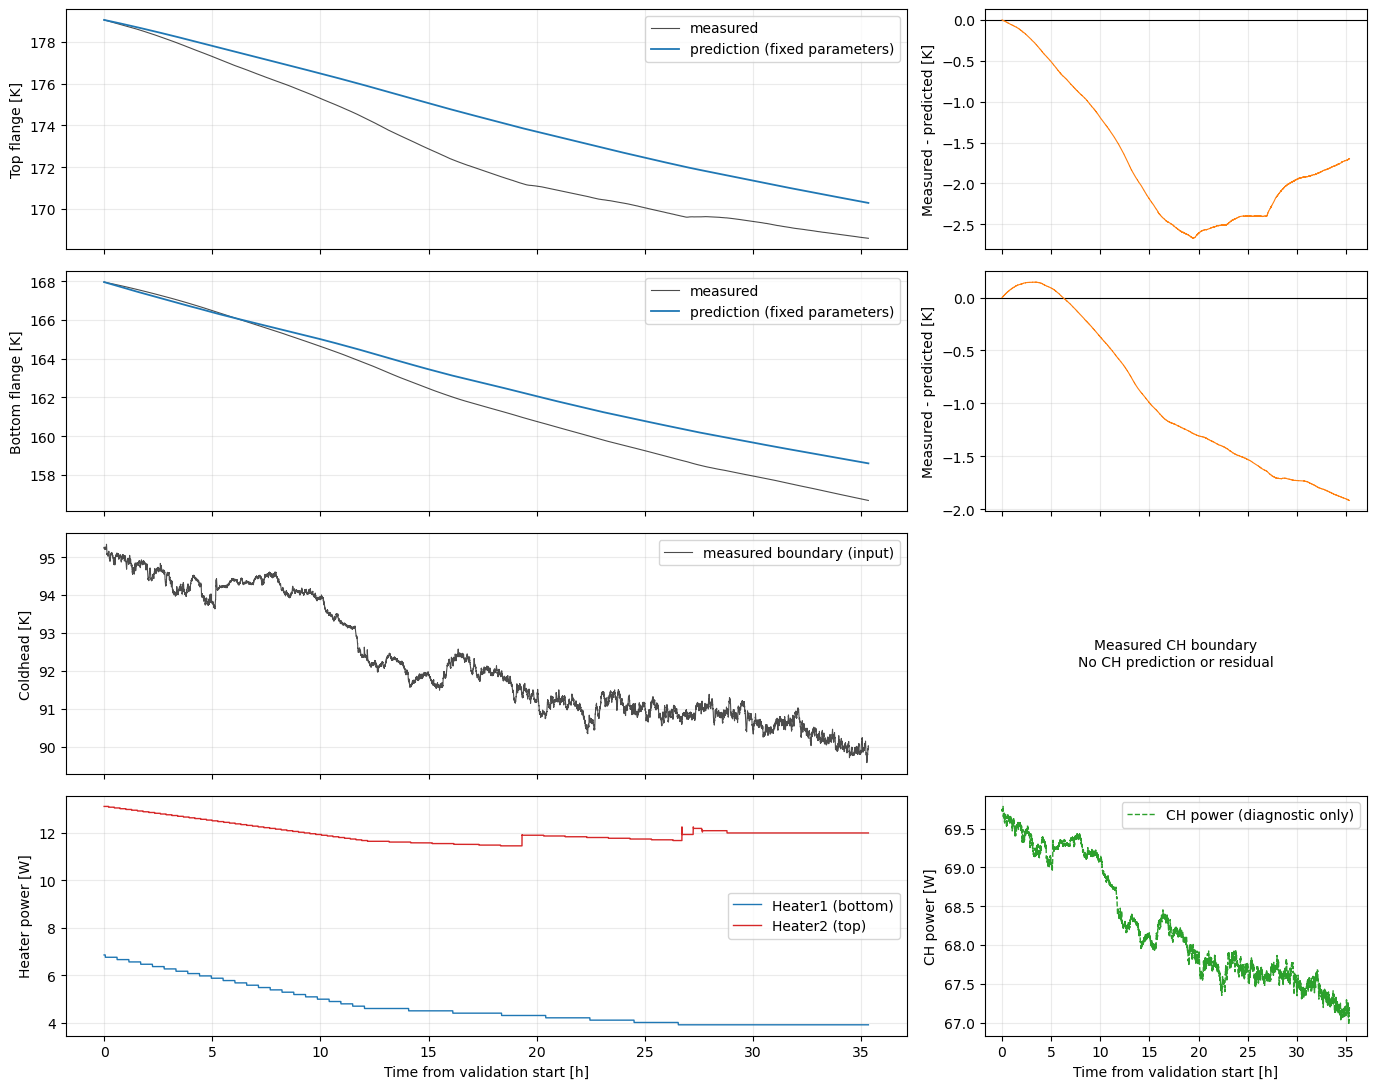

In [32]:
# %matplotlib widget
fig, axes = plot_validation(validation_result)
plt.show()
# plt.savefig("figure.png", dpi=150, bbox_inches="tight")
# plt.close()